<>:29: SyntaxWarning: invalid escape sequence '\L'
<>:29: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_2368/4065358883.py:29: SyntaxWarning: invalid escape sequence '\L'
  print(f"\Loading {num_samples} samples...")


Mounted at /content/drive
Files ready on the local disk
\Loading 80000 samples...


100%|██████████| 40/40 [09:07<00:00, 13.69s/it]



 Start Training ...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 105ms/step - accuracy: 0.7564 - auc: 0.8500 - loss: 0.7304 - val_accuracy: 0.5936 - val_auc: 0.7283 - val_loss: 1.1061 - learning_rate: 1.0000e-04
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - accuracy: 0.7893 - auc: 0.8807 - loss: 0.6621 - val_accuracy: 0.7673 - val_auc: 0.8629 - val_loss: 0.5283 - learning_rate: 1.0000e-04
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.8038 - auc: 0.8949 - loss: 0.6260 - val_accuracy: 0.6405 - val_auc: 0.8239 - val_loss: 0.7403 - learning_rate: 1.0000e-04
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - accuracy: 0.8149 - auc: 0.9026 - loss: 0.6051 - val_accuracy: 0.6812 - val_auc: 0.8202 - val_loss: 0.6584 - learning_rate: 1.0000e-04
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.8220 - auc: 0.9094 - loss: 0.5859 - val_accuracy: 0.7454 - val_auc: 0.8450 - val_loss: 0.5622 - learning_rate: 1.0000e-04
Epoch 6/50
313/313 ━━━━━━━━━

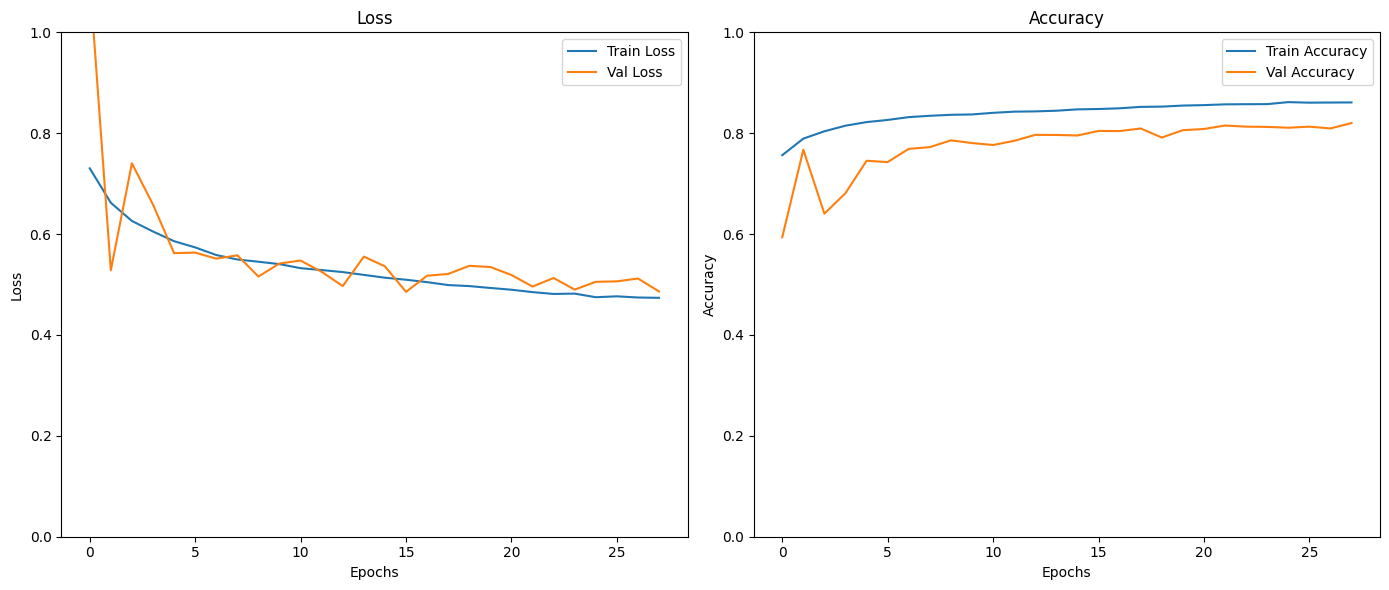


 Final evaluation on the test set...
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     Healthy       0.73      0.80      0.76     16391
       Tumor       0.78      0.71      0.74     16377

    accuracy                           0.75     32768
   macro avg       0.76      0.75      0.75     32768
weighted avg       0.76      0.75      0.75     32768



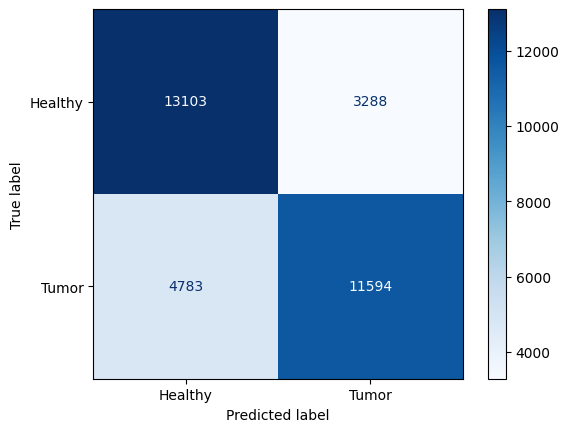

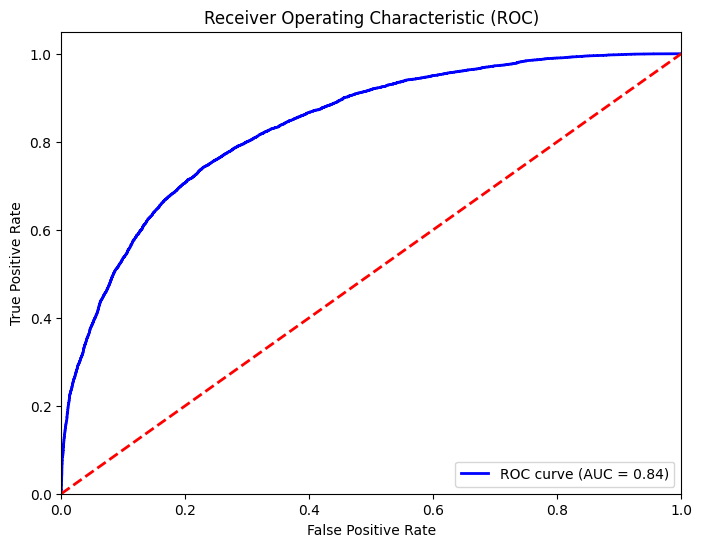

In [ ]:

from google.colab import drive
import os
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from tqdm import tqdm

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# LOCAL COPY OF FILES
for f in ['train_x','train_y','valid_x','valid_y','test_x','test_y']:
    src = f"/content/drive/MyDrive/PCam/camelyonpatch_level_2_split_{f}.h5"
    dst = f"/content/camelyonpatch_level_2_split_{f}.h5"
    if os.path.exists(src) and not os.path.exists(dst):
        !cp "$src" /content/
print("Files ready on the local disk")

np.random.seed(42)
tf.random.set_seed(42)


# LOADING DATA (80k)

def load_to_ram_optimized(x_path, y_path, num_samples=80000):
    print(f"\Loading {num_samples} samples...")
    with h5py.File(y_path, 'r') as fy:
        y_all = fy['y'][:].reshape(-1)
        idx_0 = np.where(y_all == 0)[0]
        idx_1 = np.where(y_all == 1)[0]
        n = num_samples // 2
        indices = np.sort(np.concatenate([
            np.random.choice(idx_0, n, replace=False),
            np.random.choice(idx_1, n, replace=False)
        ]))
        y_final = y_all[indices].reshape(-1, 1)

    x_final = np.empty((num_samples, 96, 96, 3), dtype='uint8')
    with h5py.File(x_path, 'r') as fx:
        ds = fx['x']
        batch_size = 2000
        for i in tqdm(range(0, num_samples, batch_size)):
            end = min(i + batch_size, num_samples)
            x_final[i:end] = ds[indices[i:end]]

    p = np.random.permutation(len(x_final))
    return x_final[p], y_final[p]

X_train, Y_train = load_to_ram_optimized('/content/camelyonpatch_level_2_split_train_x.h5',
                                         '/content/camelyonpatch_level_2_split_train_y.h5', 80000)

with h5py.File('/content/camelyonpatch_level_2_split_valid_x.h5','r') as fx, \
     h5py.File('/content/camelyonpatch_level_2_split_valid_y.h5','r') as fy:
    X_val, Y_val = fx['x'][:8000], fy['y'][:8000].reshape(-1,1)


# Model

tf.keras.mixed_precision.set_global_policy('mixed_float16')
l2_val = 1e-4

model = models.Sequential([

    layers.Input(shape=(96,96,3)),

    # Data Augmentation / Pre processing
    layers.CenterCrop(72, 72),
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),

    # 1st Level
    layers.Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(l2_val)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.SpatialDropout2D(0.1),

    # 2nd Level
    layers.Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(l2_val)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # 3rd Level
    layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(l2_val)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.SpatialDropout2D(0.2),

    # 4th level
    layers.Conv2D(256, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(l2_val)),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_val)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid', dtype='float32')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)


# TRAINING PHASE

class_weights = {0: 1.0, 1: 2.0}

callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]

print("\n Start Training ...")
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weights,
    callbacks=callbacks_list,
    verbose=1
)

# FINAL SAVE OF THE MODEL
model.save('/content/drive/MyDrive/PCam/CNN_from_scratch.keras')
print("Model saved successfully to Google Drive")


# PLOT OF FIGURES
plt.figure(figsize=(14,6))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss"); plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.ylim(0, 1.0); plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy"); plt.xlabel("Epochs"); plt.ylabel("Accuracy")
plt.ylim(0, 1.0); plt.legend()

plt.tight_layout()
plt.show()


# FINAL TEST EVALUATION
print("\n Final evaluation on the test set...")
with h5py.File('/content/camelyonpatch_level_2_split_test_x.h5','r') as fx, \
     h5py.File('/content/camelyonpatch_level_2_split_test_y.h5','r') as fy:
    X_test, Y_test = fx['x'][:], fy['y'][:].reshape(-1,1)

y_pred = model.predict(X_test, batch_size=256)
y_pred_class = (y_pred > 0.4).astype(int)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(Y_test, y_pred_class, target_names=["Healthy","Tumor"]))

cm = confusion_matrix(Y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy","Tumor"])
disp.plot(cmap='Blues')
plt.show()

# ROC Curve plotting
fpr, tpr, thresholds = roc_curve(Y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", lw=2, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()